In [1]:
# Install required libraries
!pip install ccxt ta backtesting xgboost --quiet

# Import everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ccxt
import ta
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from backtesting import Backtest, Strategy
from scipy import stats

print("✅ All libraries loaded")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.8/151.8 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.1/192.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 kB 9.5 MB/s eta 0:00:00
✅ All libraries loaded


/usr/local/lib/python3.12/dist-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


In [2]:
# Download BTC daily price data from Kraken
exchange = ccxt.kraken()
since = exchange.parse8601('2023-01-01T00:00:00Z')

print("Fetching BTC daily data from Kraken...")
ohlcv = exchange.fetch_ohlcv('BTC/USDT', '1d', since=since, limit=720)

# Convert to DataFrame
df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
df['date'] = pd.to_datetime(df['timestamp'], unit='ms')
df = df[['date', 'open', 'high', 'low', 'close', 'volume']]

print(f"Got {len(df)} days of data")
print(df.head())

Fetching BTC daily data from Kraken...
Got 720 days of data
        date     open     high      low    close      volume
0 2024-07-15  60808.1  64823.6  60739.4  64823.6  334.863844
1 2024-07-16  64723.4  65323.3  62430.1  65069.7  312.165645
2 2024-07-17  65069.7  66056.9  63870.0  64156.2  173.989035
3 2024-07-18  64118.8  65099.8  63263.4  63975.2  208.933795
4 2024-07-19  63970.4  67387.2  63355.2  66670.0  357.843425


Annualized Return: 9.21%
Annualized Volatility: 45.99%
Buy & Hold Sharpe: 0.20


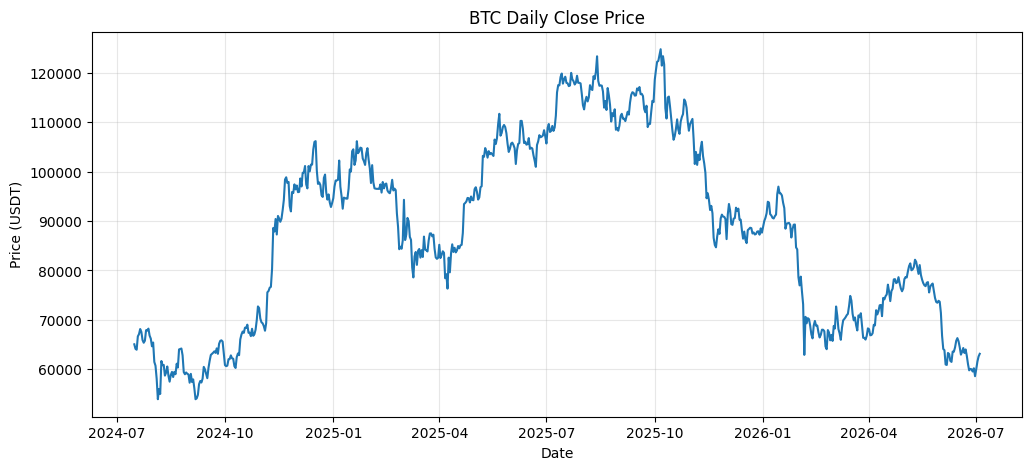

In [3]:
# Calculate daily returns
df['daily_return'] = df['close'].pct_change()
df = df.dropna().reset_index(drop=True)

# Quick stats
annual_return = df['daily_return'].mean() * 365
annual_volatility = df['daily_return'].std() * np.sqrt(365)
sharpe_ratio = annual_return / annual_volatility

print(f"Annualized Return: {annual_return*100:.2f}%")
print(f"Annualized Volatility: {annual_volatility*100:.2f}%")
print(f"Buy & Hold Sharpe: {sharpe_ratio:.2f}")

# Plot BTC price
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['close'])
plt.title('BTC Daily Close Price')
plt.xlabel('Date')
plt.ylabel('Price (USDT)')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# Add technical indicators
df['sma_20'] = df['close'].rolling(20).mean()
df['sma_50'] = df['close'].rolling(50).mean()
df['rsi_14'] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()

# MACD
macd = ta.trend.MACD(close=df['close'])
df['macd'] = macd.macd()
df['macd_diff'] = macd.macd_diff()

# Bollinger Bands
bb = ta.volatility.BollingerBands(close=df['close'], window=20, window_dev=2)
df['bb_width'] = (bb.bollinger_hband() - bb.bollinger_lband()) / bb.bollinger_mavg()

# ATR (volatility)
df['atr_14'] = ta.volatility.AverageTrueRange(
    high=df['high'], low=df['low'], close=df['close'], window=14
).average_true_range()

# 20-day rolling volatility
df['volatility_20d'] = df['daily_return'].rolling(20).std() * np.sqrt(365)

print("Technical indicators added")
print(df.tail())

Technical indicators added
          date     open     high      low    close      volume  daily_return  \
714 2026-06-30  60200.1  60251.2  58206.2  58620.3  158.867535     -0.026692   
715 2026-07-01  58645.7  61300.0  57829.4  60016.8  192.708336      0.023823   
716 2026-07-02  60020.5  62194.6  59602.4  61558.5  158.083222      0.025688   
717 2026-07-03  61562.0  62945.3  61253.6  62610.8   82.994271      0.017094   
718 2026-07-04  62589.3  63459.6  62342.3  63148.8   71.656484      0.008593   

        sma_20     sma_50     rsi_14         macd   macd_diff  bb_width  \
714  62710.065  68567.874  30.135758 -2364.540909  -47.667517  0.144178   
715  62530.995  68158.300  37.119722 -2274.759738   33.690923  0.148654   
716  62430.745  67803.304  43.799071 -2055.510562  202.352080  0.148671   
717  62339.575  67433.752  47.869463 -1776.365360  385.197825  0.145993   
718  62208.645  67114.242  49.868544 -1494.500996  533.649751  0.137983   

          atr_14  volatility_20d  
714  2

In [5]:
# Distance from moving averages
df['price_vs_sma20'] = (df['close'] - df['sma_20']) / df['sma_20']
df['price_vs_sma50'] = (df['close'] - df['sma_50']) / df['sma_50']
df['sma20_vs_sma50'] = (df['sma_20'] - df['sma_50']) / df['sma_50']

# Recent returns (momentum)
df['return_1d'] = df['close'].pct_change(1)
df['return_3d'] = df['close'].pct_change(3)
df['return_7d'] = df['close'].pct_change(7)

# Volume features
df['volume_change'] = df['volume'].pct_change()
df['volume_ma_ratio'] = df['volume'] / df['volume'].rolling(20).mean()

# Day of week
df['dow'] = df['date'].dt.dayofweek

# TARGET: Did BTC go up tomorrow? (1 = up, 0 = down)
df['next_return'] = df['close'].pct_change().shift(-1)
df['target'] = (df['next_return'] > 0).astype(int)

# Features to use in ML
feature_cols = [
    'rsi_14', 'macd', 'macd_diff', 'bb_width', 'atr_14',
    'volatility_20d', 'price_vs_sma20', 'price_vs_sma50',
    'sma20_vs_sma50', 'return_1d', 'return_3d', 'return_7d',
    'volume_change', 'volume_ma_ratio', 'dow'
]

# Drop rows with missing values
df_clean = df.dropna(subset=feature_cols + ['target']).reset_index(drop=True)

X = df_clean[feature_cols]
y = df_clean['target']

print(f"Total rows: {len(df_clean)}")
print(f"Features: {len(feature_cols)}")
print(f"Up days: {y.mean()*100:.1f}% | Down days: {(1-y.mean())*100:.1f}%")

Total rows: 670
Features: 15
Up days: 50.7% | Down days: 49.3%


In [6]:
# IMPORTANT: For time-series, we split by TIME, not randomly
# This prevents "data leakage" (using future data to predict the past)
split_point = int(len(X) * 0.80)

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]
y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]

print(f"Training set: {len(X_train)} days ({df_clean['date'].iloc[0].date()} to {df_clean['date'].iloc[split_point-1].date()})")
print(f"Test set: {len(X_test)} days ({df_clean['date'].iloc[split_point].date()} to {df_clean['date'].iloc[-1].date()})")

Training set: 536 days (2024-09-03 to 2026-02-20)
Test set: 134 days (2026-02-21 to 2026-07-04)


In [7]:
# Train XGBoost classifier
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"           Predicted DOWN | Predicted UP")
print(f"Actual DOWN:   {cm[0,0]}         |   {cm[0,1]}")
print(f"Actual UP:     {cm[1,0]}         |   {cm[1,1]}")

Test Accuracy: 55.22%
Precision: 52.50%
Recall: 65.62%

Confusion Matrix:
           Predicted DOWN | Predicted UP
Actual DOWN:   32         |   38
Actual UP:     22         |   42


Top 5 features:
            Feature  Importance
14              dow    0.081685
1              macd    0.073605
11        return_7d    0.072653
13  volume_ma_ratio    0.071531
5    volatility_20d    0.071038


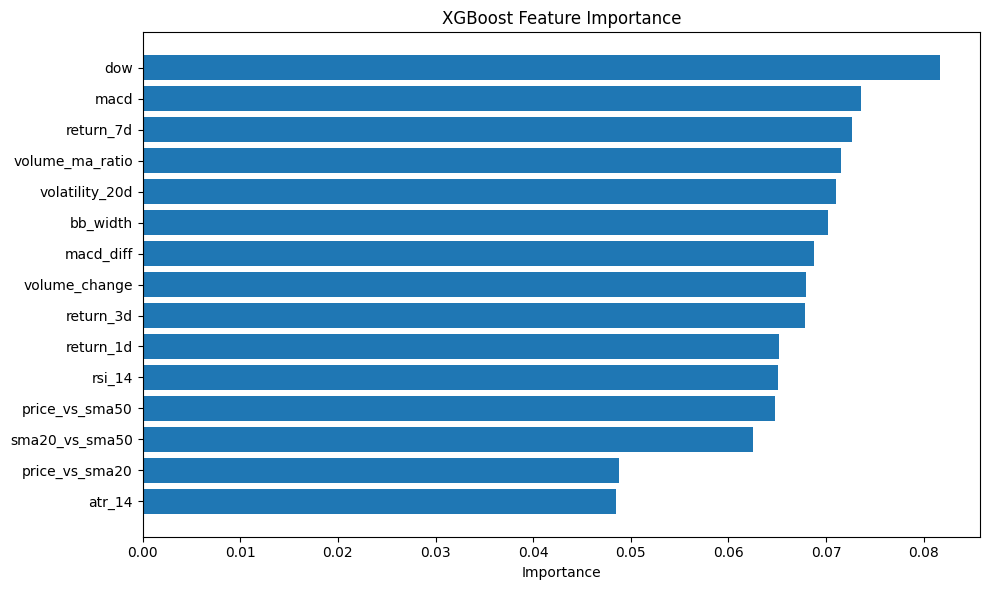

In [8]:
# See which features the model found useful
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 5 features:")
print(importance_df.head())

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1])
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

In [9]:
# Prepare data for backtesting
data = df_clean[['date', 'open', 'high', 'low', 'close', 'volume']].copy()
data.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
data.set_index('Date', inplace=True)

# Scale prices down 1000x so backtester can trade whole units
SCALE = 1000
for col in ['Open', 'High', 'Low', 'Close']:
    data[col] = data[col] / SCALE

# Simple trend-following strategy with stop-loss
class RuleStrategy(Strategy):
    def init(self):
        close = pd.Series(self.data.Close)
        self.sma_20 = self.I(lambda: close.rolling(20).mean())
        self.sma_50 = self.I(lambda: close.rolling(50).mean())
        self.rsi = self.I(lambda: ta.momentum.RSIIndicator(close, 14).rsi())

    def next(self):
        price = self.data.Close[-1]
        uptrend = self.sma_20[-1] > self.sma_50[-1]

        if not self.position:
            if uptrend and 40 < self.rsi[-1] < 65:
                self.buy(sl=price*0.95, tp=price*1.15)
            elif not uptrend and 35 < self.rsi[-1] < 60:
                self.sell(sl=price*1.05, tp=price*0.85)
        else:
            if self.position.is_long and not uptrend:
                self.position.close()
            elif self.position.is_short and uptrend:
                self.position.close()

bt_rule = Backtest(data, RuleStrategy, cash=100000, commission=0.001, exclusive_orders=True, margin=1.0)
stats_rule = bt_rule.run()

print("RULE-BASED STRATEGY RESULTS")
print(f"Return: {stats_rule['Return [%]']:.2f}%")
print(f"Sharpe: {stats_rule['Sharpe Ratio']:.2f}")
print(f"Max Drawdown: {stats_rule['Max. Drawdown [%]']:.2f}%")
print(f"Trades: {stats_rule['# Trades']}")
print(f"Win Rate: {stats_rule['Win Rate [%]']:.2f}%")

Backtest.run:   0%|          | 0/620 [00:00<?, ?bar/s]

RULE-BASED STRATEGY RESULTS
Return: 4.79%
Sharpe: 0.07
Max Drawdown: -38.17%
Trades: 43
Win Rate: 32.56%


/tmp/ipykernel_6118/395892113.py:35: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and include them in stats.
  stats_rule = bt_rule.run()


In [11]:
# Get ML predictions for the whole dataset
all_probas = model.predict_proba(X)[:, 1]
df_clean['ml_prob_up'] = all_probas

# Create signals: only trade on high confidence
df_clean['ml_signal'] = 0
df_clean.loc[df_clean['ml_prob_up'] >= 0.60, 'ml_signal'] = 1   # long
df_clean.loc[df_clean['ml_prob_up'] <= 0.40, 'ml_signal'] = -1  # short

# Only backtest on TEST period (data model never saw)
test_df = df_clean.iloc[split_point:].copy()
bt_data = test_df[['date', 'open', 'high', 'low', 'close', 'volume', 'ml_signal']].copy()
bt_data.columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'ml_signal']
bt_data.set_index('Date', inplace=True)
for col in ['Open', 'High', 'Low', 'Close']:
    bt_data[col] = bt_data[col] / SCALE

# ML strategy with high-confidence entries
class MLStrategy(Strategy):
    def init(self):
        self.signal = self.data.ml_signal
        self.days_held = 0

    def next(self):
        price = self.data.Close[-1]
        sig = self.signal[-1]

        if not self.position:
            if sig == 1:
                self.buy(sl=price*0.95, tp=price*1.12)
                self.days_held = 0
            elif sig == -1:
                self.sell(sl=price*1.05, tp=price*0.88)
                self.days_held = 0
        else:
            self.days_held += 1
            if self.days_held >= 7:
                self.position.close()
            elif self.position.is_long and sig == -1:
                self.position.close()
            elif self.position.is_short and sig == 1:
                self.position.close()

bt_ml = Backtest(bt_data, MLStrategy, cash=100000, commission=0.001, exclusive_orders=True, margin=1.0)
stats_ml = bt_ml.run()

print("ML STRATEGY RESULTS (Out-of-Sample Test Period)")
print(f"Return: {stats_ml['Return [%]']:.2f}%")
print(f"Sharpe: {stats_ml['Sharpe Ratio']:.2f}")
print(f"Max Drawdown: {stats_ml['Max. Drawdown [%]']:.2f}%")
print(f"Trades: {stats_ml['# Trades']}")
print(f"Win Rate: {stats_ml['Win Rate [%]']:.2f}%")

Backtest.run:   0%|          | 0/133 [00:00<?, ?bar/s]

ML STRATEGY RESULTS (Out-of-Sample Test Period)
Return: 1.84%
Sharpe: 0.12
Max Drawdown: -24.36%
Trades: 21
Win Rate: 52.38%


In [12]:
# Final comparison and plot
print("=" * 55)
print("STRATEGY COMPARISON")
print("=" * 55)
print(f"{'Metric':<20} {'Rule-Based':<15} {'ML (XGBoost)':<15}")
print("-" * 55)
print(f"{'Return [%]':<20} {stats_rule['Return [%]']:<15.2f} {stats_ml['Return [%]']:<15.2f}")
print(f"{'Sharpe Ratio':<20} {stats_rule['Sharpe Ratio']:<15.2f} {stats_ml['Sharpe Ratio']:<15.2f}")
print(f"{'Max Drawdown [%]':<20} {stats_rule['Max. Drawdown [%]']:<15.2f} {stats_ml['Max. Drawdown [%]']:<15.2f}")
print(f"{'Win Rate [%]':<20} {stats_rule['Win Rate [%]']:<15.2f} {stats_ml['Win Rate [%]']:<15.2f}")
print(f"{'# Trades':<20} {stats_rule['# Trades']:<15} {stats_ml['# Trades']:<15}")

# Plot the ML strategy
bt_ml.plot(resample=False)

STRATEGY COMPARISON
Metric               Rule-Based      ML (XGBoost)   
-------------------------------------------------------
Return [%]           4.79            1.84           
Sharpe Ratio         0.07            0.12           
Max Drawdown [%]     -38.17          -24.36         
Win Rate [%]         32.56           52.38          
# Trades             43              21             


GridPlot(id='p1336', ...)